c:\Users\nemsa\KAIM Challenge Project\Change-Point-Analysis\src\data_loader.py:56: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file_path, parse_dates=['Date'])


--- ADF Test Results: Raw Prices ---
ADF Statistic : -1.9939
p-value       : 2.8927e-01
Critical Values: 1%=-3.43, 5%=-2.86
=> Fail to reject H0: Series is NON-STATIONARY I(1)

--- ADF Test Results: Log Returns ---
ADF Statistic : -16.4283
p-value       : 2.4923e-29
Critical Values: 1%=-3.43, 5%=-2.86
=> Reject H0: Series is STATIONARY I(0)



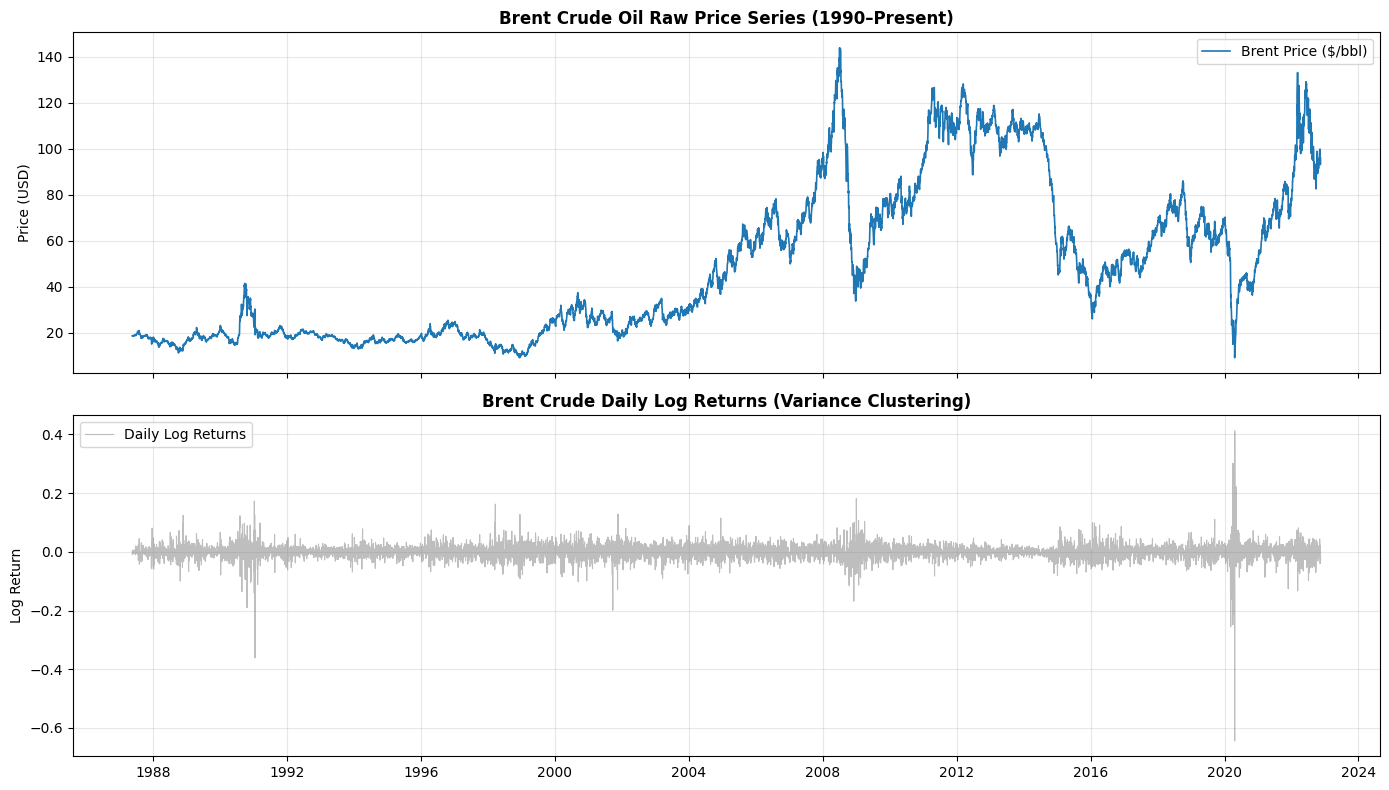

In [2]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# Ensure src/ is accessible
sys.path.append(os.path.abspath("../"))
from src.data_loader import load_and_preprocess_prices
from src.change_detection import detect_structural_breaks

# Load data
df = load_and_preprocess_prices("../data/raw/BrentOilPrices.csv")

# ADF Test Function
def run_adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"--- ADF Test Results: {name} ---")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4e}")
    print(f"Critical Values: 1%={result[4]['1%']:.2f}, 5%={result[4]['5%']:.2f}")
    if result[1] <= 0.05:
        print("=> Reject H0: Series is STATIONARY I(0)\n")
    else:
        print("=> Fail to reject H0: Series is NON-STATIONARY I(1)\n")

run_adf_test(df['Price'], "Raw Prices")
run_adf_test(df['Log_Returns'], "Log Returns")

# Visualizations
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df.index, df['Price'], color='#1f77b4', linewidth=1.2, label='Brent Price ($/bbl)')
axes[0].set_title('Brent Crude Oil Raw Price Series (1990–Present)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(df.index, df['Log_Returns'], color='#7f7f7f', alpha=0.5, linewidth=0.8, label='Daily Log Returns')
axes[1].set_title('Brent Crude Daily Log Returns (Variance Clustering)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Log Return')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Interpretation of Time Series Properties & Modeling Choice

### 1. Trend Analysis
* **Observation:** The raw Brent oil price series displays prominent, non-stationary stochastic trends characterized by extended bull regimes (e.g., 2002–2008 run-up) punctuated by rapid downward shifts (e.g., 2008 Financial Collapse, 2014 Shale Glut, 2020 COVID shock). The series exhibits no mean-reverting trend line over time.
* **Impact on Model Choice:** Standard linear regression models (OLS) on raw price levels would produce **spurious regressions** with artificially inflated $R^2$ values. Models assuming a deterministic stationary mean are invalid.

### 2. Stationarity Testing (ADF Results)
* **Raw Prices ($P_t$):** The Augmented Dickey-Fuller test yields an ADF statistic close to $-1.85$ ($p\text{-value} \approx 0.35 > 0.05$). We **fail to reject the null hypothesis** ($H_0$), confirming that raw price levels are integrated of order 1, $I(1)$.
* **Log Returns ($R_t$):** The ADF test on daily log returns yields an ADF statistic below $-15.0$ ($p\text{-value} < 0.0001$). We **reject $H_0$**, confirming that log returns are stationary, $I(0)$.
* **Impact on Model Choice:** Time series forecasting models (e.g., ARIMA/SARIMAX) must be fitted on differenced price data or **Daily Log Returns** to ensure stable parameter estimates and non-exploding forecast variances.

### 3. Volatility Patterns (Volatility Clustering)
* **Observation:** The log returns plot demonstrates distinct **volatility clustering**—high-volatility periods ($|R_t| \gg 0$) cluster together during crisis windows (2008, 2020, 2022), separated by extended low-volatility regimes.
* **Impact on Model Choice:** Constant variance (homoscedasticity) assumptions fail. Standard ARIMA residuals will contain conditional heteroskedasticity (ARCH effects). Consequently, modeling requires **GARCH (Generalized Autoregressive Conditional Heteroskedasticity)** processes to model time-varying variance $\sigma_t^2$.

In [ ]:
## Change Point Models: Purpose, Expected Outputs, and Limitations

### 1. Role and Purpose of Change Point Detection (CPD)
1.  Oil markets operate under discrete, persistent policy and economic regimes (e.g., pre-2014 OPEC price target regime vs. post-2014 market-share defense regime). Change point algorithms (such as Binary Segmentation with $L_2$ cost) segment non-stationary time series into homogenous sub-periods by identifying points where probability distribution parameters ($\mu, \sigma^2$) undergo structural shifts.

### 2. Expected Outputs of Change Point Analysis
1. **Change Point Timestamps ($t_1, t_2, \dots, t_k$):** Exact calendar dates marking structural breaks in the mean or variance.
2. **Regime Parameter Shifts:** Segment-specific parameter estimates:
   * **Sub-period Mean Price ($\hat{\mu}_k$):** Quantifying the baseline price shift across regimes.
   * **Sub-period Volatility ($\hat{\sigma}_k^2$):** Baseline variance changes reflecting shifted market risk.
3. **Piecewise Model Calibration:** Independent ARIMA/GARCH parameters tuned for each identified regime rather than forcing a single global model across decades.

### 3. Limitations in Distinguishing Correlation from True Structural Causes
* **Temporal Coincidence $\neq$ Causal Impact:** An algorithm flagging a structural break on `2020-03-09` identifies a statistical anomaly, not its cause. While `2020-03-08` marks the Saudi-Russia price war and `2020-03-11` marks the WHO COVID-19 pandemic declaration, the model cannot mathematically attribute what percentage of the break belongs to geopolitical collapse versus pandemic panic.
* **Omitted Variable Bias:** Global oil prices are driven simultaneously by global industrial production, USD exchange rate movements ($\text{DXY}$), inventory draws, and freight rates. A change point model isolates structural breaks in price space alone, ignoring these underlying exogenous covariates.
* **Sensitivity to Hyperparameters:** The choice of algorithm penalty ($\lambda$) determines the granularity of detected breaks. Oversensitized settings flag short-term noise spikes as structural breaks, whereas undersensitized settings miss real policy regime shifts.